
# INF-473 - Introducción a la Inteligencia Artificial Explicable
## 1er Semestre 2026 -- Prof. Raquel Pezoa

## Actividad 0
___
* *Objetivo*: Usar Jupyter notebooks y familiarizarse con las herramientas de Python para generar un modelo ML (una red feed forward tradicional) aplicado en datos de física de partículas.



In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from pathlib import Path
import gdown

# 1. Problem:
The problem is to identify the signal from the background, where the signal corresponds to a Higgs boson decaying to a pair of bottom quarks according to the process:
$$gg \rightarrow H^0 \rightarrow W^{\mp} H^{\pm} \rightarrow W^{\mp} W^{\pm} h^0 \rightarrow W^{\mp} W^{\pm} b \bar{b}$$

# Datos

In [2]:

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

FILE_ID = "1OGThsYLPzRZDY8uKpMNc61uL30uVwxS_"
DATA_FILE = DATA_DIR / "higgs.csv"

if not DATA_FILE.exists():
    url = f"https://drive.google.com/uc?id={FILE_ID}"
    gdown.download(url, str(DATA_FILE), quiet=False)

df = pd.read_csv(DATA_FILE)
df.head()

Downloading...
From: https://drive.google.com/uc?id=1OGThsYLPzRZDY8uKpMNc61uL30uVwxS_
To: /content/data/higgs.csv
100%|██████████| 45.4M/45.4M [00:00<00:00, 61.0MB/s]
/tmp/ipykernel_8238/3079588584.py:11: DtypeWarning: Columns (20,21,22,23,24,25,26,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_FILE)


,class,lepton_pT,lepton_eta,lepton_phi,missing_energy_magnitude,missing_energy_phi,jet1pt,jet1eta,jet1phi,jet1b-tag,...,jet4eta,jet4phi,jet4b-tag,m_jj,m_jjj,m_lv,m_jlv,m_bb,m_wbb,m_wwbb
0,1,0.907542,0.329147,0.359412,1.497970,-0.313010,1.095531,-0.557525,-1.588230,2.173076,...,-1.138930,-0.000819,0.0,0.30222,0.833048,0.9857,0.978098,0.779732,0.992356,0.798343
1,1,0.798835,1.470639,-1.635975,0.453773,0.425629,1.104875,1.282322,1.381664,0.000000,...,1.128848,0.900461,0.0,0.909753,1.10833,0.985692,0.951331,0.803252,0.865924,0.780118
2,0,1.344385,-0.876626,0.935913,1.992050,0.882454,1.786066,-1.646778,-0.942383,0.000000,...,-0.678379,-1.360356,0.0,0.946652,1.028704,0.998656,0.728281,0.8692,1.026736,0.957904
3,1,1.105009,0.321356,1.522401,0.882808,-1.205349,0.681466,-1.070464,-0.921871,0.000000,...,-0.373566,0.113041,0.0,0.755856,1.361057,0.98661,0.838085,1.133295,0.872245,0.808487
4,0,1.595839,-0.607811,0.007075,1.818450,-0.111906,0.847550,-0.566437,1.581239,2.173076,...,-0.654227,-1.274345,3.101961,0.823761,0.938191,0.971758,0.789176,0.430553,0.961357,0.957818


## Preprocessing

In [3]:
df.drop(df.tail(1).index,inplace=True) # drop last n rows
df = df.apply(pd.to_numeric)

In [4]:
df.head()

,class,lepton_pT,lepton_eta,lepton_phi,missing_energy_magnitude,missing_energy_phi,jet1pt,jet1eta,jet1phi,jet1b-tag,...,jet4eta,jet4phi,jet4b-tag,m_jj,m_jjj,m_lv,m_jlv,m_bb,m_wbb,m_wwbb
0,1,0.907542,0.329147,0.359412,1.497970,-0.313010,1.095531,-0.557525,-1.588230,2.173076,...,-1.138930,-0.000819,0.000000,0.302220,0.833048,0.985700,0.978098,0.779732,0.992356,0.798343
1,1,0.798835,1.470639,-1.635975,0.453773,0.425629,1.104875,1.282322,1.381664,0.000000,...,1.128848,0.900461,0.000000,0.909753,1.108330,0.985692,0.951331,0.803252,0.865924,0.780118
2,0,1.344385,-0.876626,0.935913,1.992050,0.882454,1.786066,-1.646778,-0.942383,0.000000,...,-0.678379,-1.360356,0.000000,0.946652,1.028704,0.998656,0.728281,0.869200,1.026736,0.957904
3,1,1.105009,0.321356,1.522401,0.882808,-1.205349,0.681466,-1.070464,-0.921871,0.000000,...,-0.373566,0.113041,0.000000,0.755856,1.361057,0.986610,0.838085,1.133295,0.872245,0.808487
4,0,1.595839,-0.607811,0.007075,1.818450,-0.111906,0.847550,-0.566437,1.581239,2.173076,...,-0.654227,-1.274345,3.101961,0.823761,0.938191,0.971758,0.789176,0.430553,0.961357,0.957818


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [6]:
y = df["class"]
X = df.iloc[:,1:]

from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler = MinMaxScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)

scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(scaled_data,y, test_size=0.2, random_state=0)

# TODO:
***

* Entrenar una red neuronal para **clasificar** entre señal (etiqueta = 1) y background (etiqueta=0).
* La rede debe predecir un *score* entre 0 y 1, donde valores cercanos a 0 indican que el evento es de la clase 0 (o brackground) y valores cercanos a 1 indica que el evento es clase 1 (o señal). **¿Cuántas neuronas y cuál función de activación debe tener la última capa?**
* Graficar un histograma con las predicciones de la red en los datos de testing
* Mostrar desempeños
* Comente los resultados





In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Crear el modelo (la arquitectura)
model = models.Sequential([
    # Capa de entrada: 29 neuronas (una por columna) [cite: 218]
    # Capas ocultas: Usamos ReLU para que los "analistas" filtren la info [cite: 29]
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),

    # Capa de salida: 1 neurona con SIGMOIDE para el score 0-1
    layers.Dense(1, activation='sigmoid')
])

# 2. Compilar el modelo
model.compile(optimizer='adam',
              loss='binary_crossentropy', # Ideal para clasificar 0 o 1
              metrics=['accuracy'])

# 3. Entrenar (aquí la red "estudia" las filas)
history = model.fit(X_train, y_train,
                    epochs=10,           # Cuántas veces lee todo el libro
                    batch_size=32,       # Grupos de filas que lee a la vez
                    validation_split=0.1, # Deja un poco para autoevaluarse
                    verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
2207/2207 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6493 - loss: 0.6237 - val_accuracy: 0.6730 - val_loss: 0.6052
Epoch 2/10
2207/2207 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6873 - loss: 0.5878 - val_accuracy: 0.6900 - val_loss: 0.5874
Epoch 3/10
2207/2207 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7005 - loss: 0.5709 - val_accuracy: 0.6943 - val_loss: 0.5807
Epoch 4/10
2207/2207 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7090 - loss: 0.5599 - val_accuracy: 0.7017 - val_loss: 0.5676
Epoch 5/10
2207/2207 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7134 - loss: 0.5517 - val_accuracy: 0.7019 - val_loss: 0.5682
Epoch 6/10
2207/2207 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7179 - loss: 0.5461 - val_accuracy: 0.7056 - val_loss: 0.5644
Epoch 7/10
2207/2207 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7199 - loss: 0.5420 - val_accuracy: 0.7105 - val_loss: 0.5600
Epoch 8/10
2207/2207 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7241 - loss: 0.5378 -

613/613 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


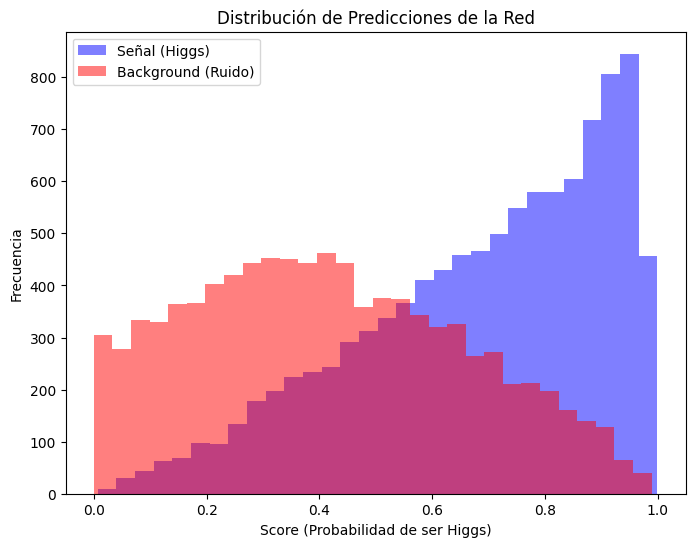

In [9]:
# Obtener los scores (predicciones) para el set de prueba
y_pred_score = model.predict(X_test)

# Graficar el Histograma
plt.figure(figsize=(8,6))
plt.hist(y_pred_score[y_test==1], bins=30, alpha=0.5, label='Señal (Higgs)', color='blue')
plt.hist(y_pred_score[y_test==0], bins=30, alpha=0.5, label='Background (Ruido)', color='red')
plt.title('Distribución de Predicciones de la Red')
plt.xlabel('Score (Probabilidad de ser Higgs)')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

In [10]:
# Convertimos el score (0.8, 0.2, etc) a una decisión final (1 o 0)
# Si el score es > 0.5, decimos que es Clase 1
y_pred_binary = (y_pred_score > 0.5).astype(int)

# Mostrar el reporte de clasificación
print(classification_report(y_test, y_pred_binary))

              precision    recall  f1-score   support

           0       0.73      0.64      0.68      9282
           1       0.71      0.79      0.75     10328

    accuracy                           0.72     19610
   macro avg       0.72      0.71      0.71     19610
weighted avg       0.72      0.72      0.71     19610

